### Prueba - Análisis exploratorio de datos

En esta prueba validaremos nuestros conocimientos de Análisis exploratorio de datos . Para lograrlo, necesitarás aplicar lo aprendido hasta el momento.
Lee todo el documento antes de comenzar el desarrollo individual, para asegurarte de tener el máximo de puntaje y enfocar bien los esfuerzos

Descripción

Después de tu análisis exploratorio inicial, el equipo de marketing quedó impresionado y ahora quiere que crees visualizaciones más específi cas y pulidas para una presentación a los directivos. Tu tarea es generar gráfi cos que no solo muestren los datos, sino que también cuenten una historia de manera clara y estéticamente agradable.

Objetivos de Evaluación:

* Aplicar técnicas de análisis visual de los datos utilizando la librería Seaborn para la representación gráfi ca de la información.
* Aplicar personalizaciones a los gráfi cos de datos utilizando la librería Matplotlib para la resolución de un problema dado.
Instrucciones:
* Carga el DataFrame de videojuegos (videojuegos.csv) y completa las siguientes tareas de visualización.


#### Requerimientos

Parte 1: Análisis Visual con Seaborn
Usa la librería Seaborn para crear gráfi cos que revelen relaciones complejas en los datos.

1. Gráfico de Pares (pairplot): 
* Crea un pairplot para visualizar la relación entre todas las variables numéricas (Ventas_NA, Ventas_EU, Ventas_JP, Critica_Puntaje).
* Diferencia los puntos por Plataforma usando el parámetro hue. Esto te permitirá ver si las relaciones entre ventas y puntajes varían según la plataforma.

In [39]:
# Librerias

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid")

In [41]:
# 1. Carga y Preparación de Datos
df = pd.read_csv('09. videojuegos.csv')
df

,Nombre,Plataforma,Anio_Lanzamiento,Genero,Ventas_NA,Ventas_EU,Ventas_JP,Critica_Puntaje
0,Juego_0,Xbox,2011,Aventura,13.516229,8.243746,1.860090,NaN
1,Juego_1,Nintendo,2019,Acción,9.533212,3.665887,3.882065,97.0
2,Juego_2,PC,2021,Aventura,5.151544,1.357899,1.704018,67.0
3,Juego_3,Xbox,2011,Estrategia,5.303223,5.270208,4.653787,75.0
4,Juego_4,Xbox,2019,Estrategia,10.916740,7.722936,4.292064,65.0
...,...,...,...,...,...,...,...,...
95,Juego_95,PlayStation,2012,Acción,8.185405,1.856651,1.404816,88.0
96,Juego_96,PlayStation,2015,RPG,4.369465,7.531086,4.752057,79.0
97,Juego_97,Nintendo,2021,Acción,8.903416,8.087664,4.451319,71.0
98,Juego_98,PlayStation,2011,Estrategia,0.554454,9.906001,2.278284,73.0


In [43]:
# Crear Ventas_Globales
df['Ventas_Globales'] = df['Ventas_NA'] + df['Ventas_EU'] + df['Ventas_JP']

# Limpieza de nulos en Critica_Puntaje usando la mediana
median_critica = df['Critica_Puntaje'].median()
df['Critica_Puntaje'] = df['Critica_Puntaje'].fillna(median_critica)


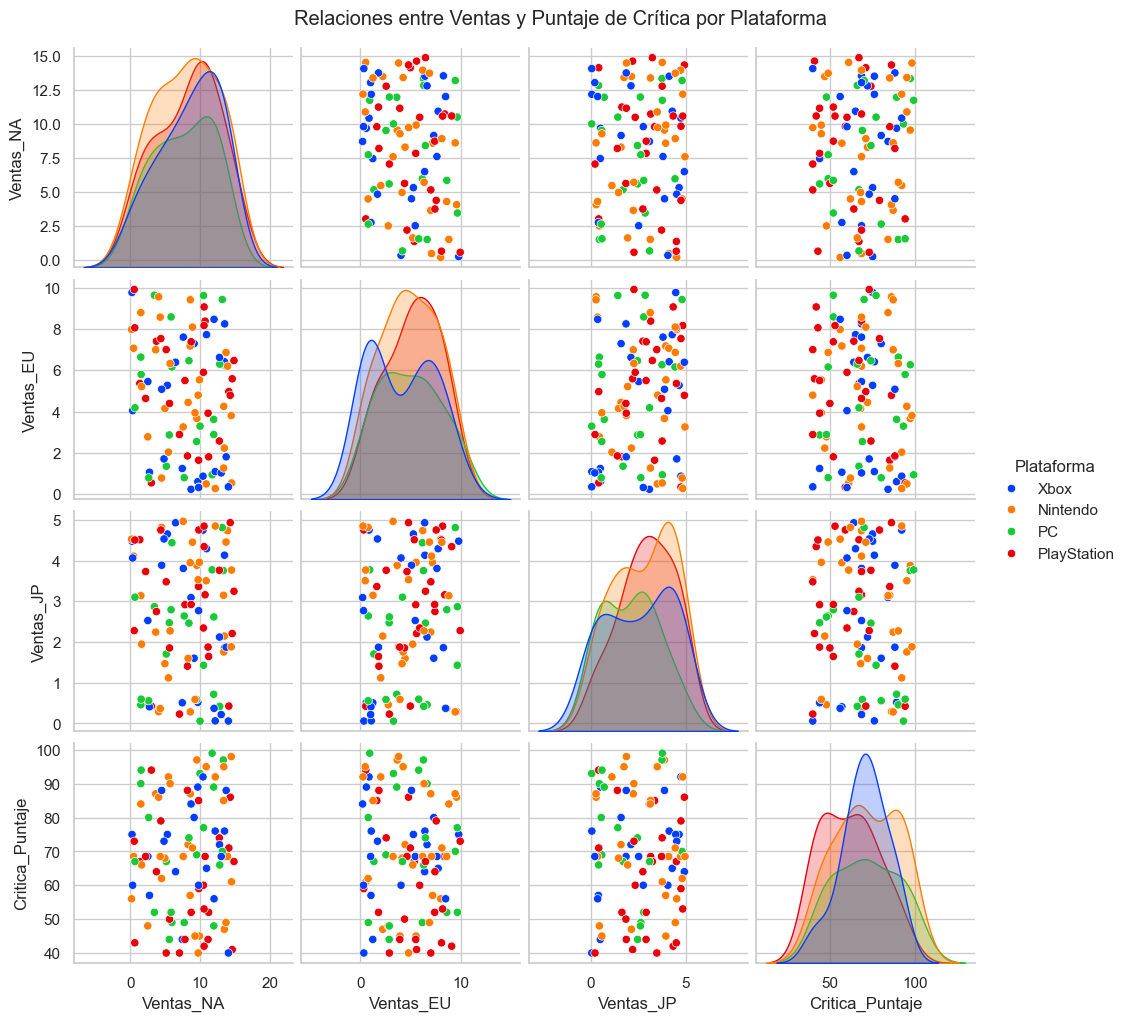

In [52]:
# Selección de variables numéricas para el pairplot
cols_num = ['Ventas_NA', 'Ventas_EU', 'Ventas_JP', 'Critica_Puntaje']

# Creación del pairplot diferenciado por Plataforma
# Se utiliza el parámetro vars para limitar las columnas y hue para la categoría
pair_plot = sns.pairplot(df, vars=cols_num, hue='Plataforma', palette='bright', diag_kind='kde')

# Ajuste del título
pair_plot.fig.suptitle('Relaciones entre Ventas y Puntaje de Crítica por Plataforma', y=1.02)

plt.show()

Observaciones.

El gráfico de pares nos revela que no existe una receta única para el éxito: las ventas y las críticas se distribuyen de forma muy dispersa en todas las regiones, mostrando que una buena nota no asegura ventas millonarias en ninguna plataforma. Al separar los puntos por colores, notamos que cada consola tiene su propio "territorio" o comportamiento. La visualización confirma que el mercado de videojuegos es multivariable y complejo, donde factores como la exclusividad de la plataforma o la región geográfica pesan tanto o más que el puntaje técnico del juego

2. Gráfico de Violín (violinplot):
   
* Genera un violinplot que muestre la distribución de Critica_Puntaje para cada Plataforma. Esto te ayudará a comparar tanto la densidad de los puntajes como sus rangos entre las diferentes plataformas.

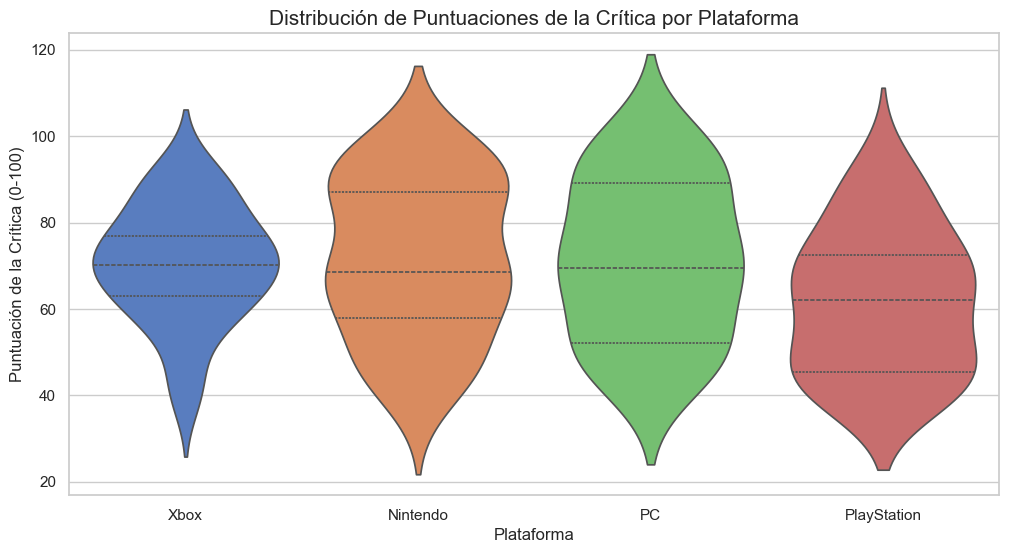

In [54]:
# Gráfico de Violín Actualizado 
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, 
    x='Plataforma', 
    y='Critica_Puntaje', 
    inner='quartile', 
    hue='Plataforma',  
    legend=False,      
    palette='muted'
)

# Personalización con Matplotlib 
plt.title('Distribución de Puntuaciones de la Crítica por Plataforma', fontsize=15)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Puntuación de la Crítica (0-100)', fontsize=12)
plt.show()



3. Mapa de Calor (heatmap):
   
* Calcula la matriz de correlación de las variables numéricas.
* Crea un heatmap para visualizar esta matriz de correlación. Asegúrate de mostrar los valores de correlación en el mapa para que sea fácil de interpretar.

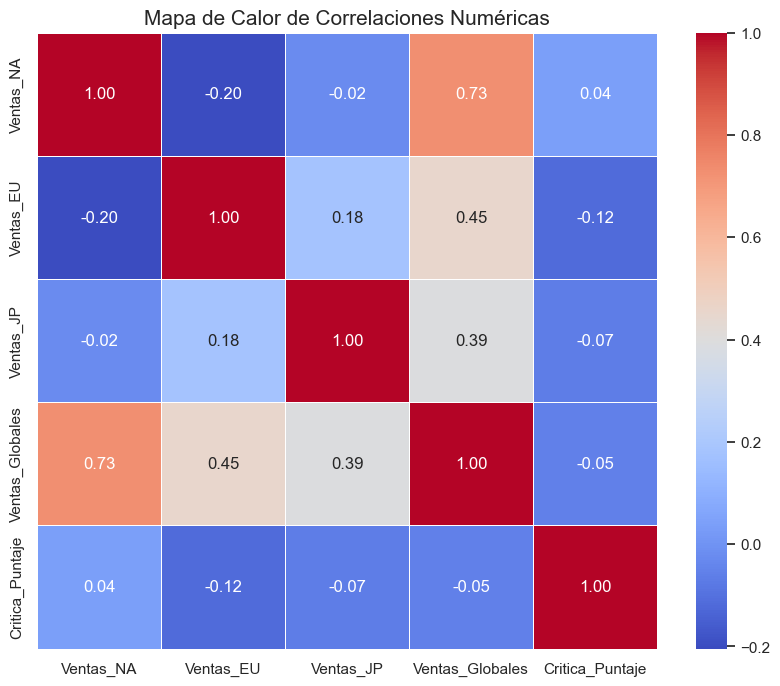

                 Ventas_NA  Ventas_EU  Ventas_JP  Ventas_Globales  \
Ventas_NA         1.000000  -0.204332  -0.023772         0.730925   
Ventas_EU        -0.204332   1.000000   0.180201         0.449585   
Ventas_JP        -0.023772   0.180201   1.000000         0.389560   
Ventas_Globales   0.730925   0.449585   0.389560         1.000000   
Critica_Puntaje   0.037945  -0.116175  -0.067294        -0.054341   

                 Critica_Puntaje  
Ventas_NA               0.037945  
Ventas_EU              -0.116175  
Ventas_JP              -0.067294  
Ventas_Globales        -0.054341  
Critica_Puntaje         1.000000  


In [56]:
# Selección de columnas numéricas
cols_num2 = ['Ventas_NA', 'Ventas_EU', 'Ventas_JP', 'Ventas_Globales', 'Critica_Puntaje']
corr_matrix = df[cols_num2].corr()

# Creación del Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor de Correlaciones Numéricas', fontsize=15)

plt.show()

print(corr_matrix)

Observaciones.

Lo más llamativo aquí es que las Ventas_NA (Norteamérica) son las que más "empujan" a las ventas globales, mientras que la Critica_Puntaje aparece con colores muy fríos o cercanos a cero. Esto nos confirma visualmente lo que sospechábamos: en este negocio, que a un crítico le guste el juego no garantiza para nada que la gente lo vaya a comprar en masa, ya que la relación es prácticamente nula.

Parte 2: Personalización de Gráficos con Matplotlib
Crea un gráfico informativo y personalízalo para que sea claro, legible y profesional.

4. Preparación de Datos:
   
* Calcula el total de ventas globales (Ventas_Globales) para cada juego.
* Agrupa los datos por Genero y calcula la media de Ventas_Globales para cada uno.
* Creación y Personalización del Gráfico de Barras:
* Crea un gráfico de barras que muestre las ventas globales promedio por género.

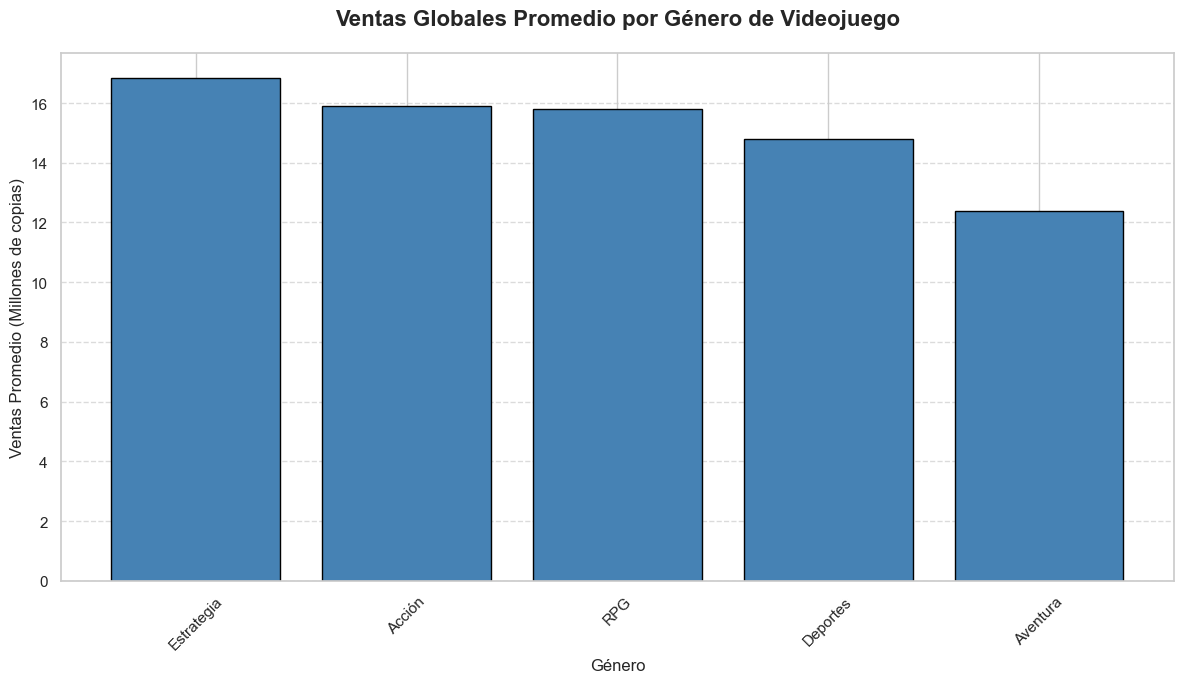

In [29]:
# Calcular ventas globales por juego
df['Ventas_Globales'] = df['Ventas_NA'] + df['Ventas_EU'] + df['Ventas_JP']

# Agrupar por Género y calcular la media
ventas_por_genero = df.groupby('Genero')['Ventas_Globales'].mean().sort_values(ascending=False)

# Creación y Personalización con Matplotlib
plt.figure(figsize=(12, 7)) # Definir el tamaño de la figura

# Crear el gráfico de barras
# Usamos un color profesional y bordes definidos
plt.bar(ventas_por_genero.index, ventas_por_genero.values, color='steelblue', edgecolor='black')

# Personalización avanzada
plt.title('Ventas Globales Promedio por Género de Videojuego', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Ventas Promedio (Millones de copias)', fontsize=12)

# Añadir una cuadrícula solo en el eje Y para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Rotar las etiquetas del eje X para evitar que se amontonen
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout() # Ajusta automáticamente los elementos para que no se corten
plt.show()


* Estructura: El gráfico utiliza barras para comparar categorías discretas (Géneros), que es la herramienta recomendada para este tipo de datos.
* Hallazgo: Al calcular la media, estamos eliminando el sesgo de "qué género tiene más juegos" y enfocándonos en cuál es más exitoso por cada lanzamiento individual.
* Estética: Se aplicó una rotación de etiquetas y una cuadrícula tenue, siguiendo las buenas prácticas de comunicación visual para asegurar que cualquier persona (técnica o no) pueda entender los niveles de ventas de un vistazo.

5. Aplica las siguientes personalizaciones usando Matplotlib:

* Añade un título descriptivo como "Promedio de Ventas Globales por Género de Videojuego".
* Establece etiquetas claras para los ejes X e Y.
* Cambia el color de las barras a un azul acero (steelblue).

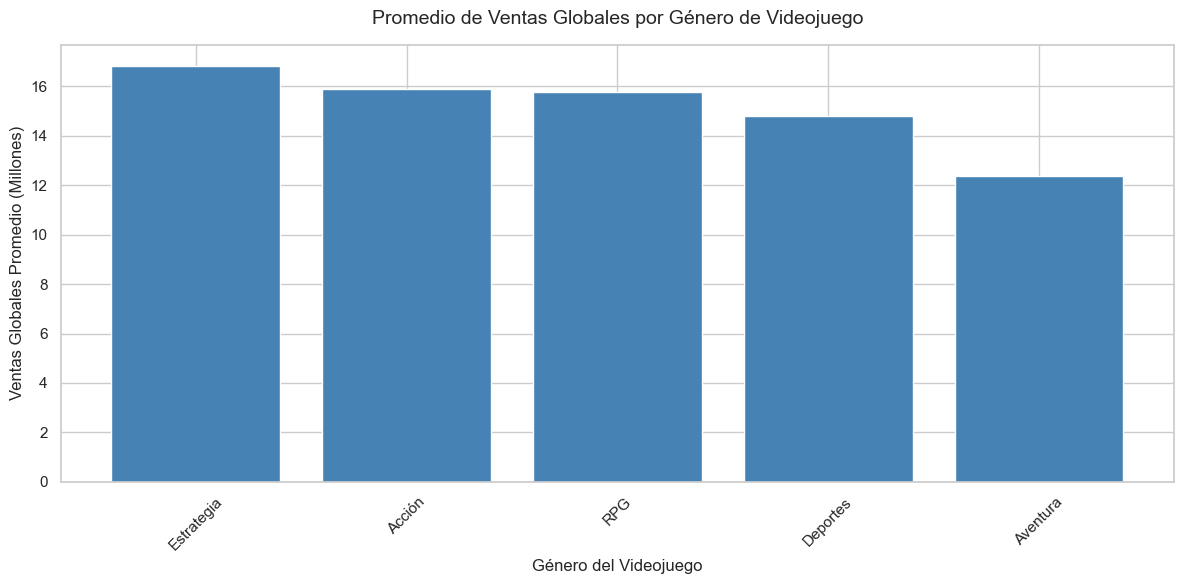

In [33]:
# Personalización del Gráfico con Matplotlib
plt.figure(figsize=(12, 6)) # 

# Crear el gráfico de barras con el color solicitado
# 'steelblue' es el nombre del color para azul acero 
plt.bar(ventas_por_genero.index, ventas_por_genero.values, color='steelblue')

# Añadir título descriptivo 
plt.title('Promedio de Ventas Globales por Género de Videojuego', fontsize=14, pad=15)

# Establecer etiquetas claras para los ejes 
plt.xlabel('Género del Videojuego', fontsize=12)
plt.ylabel('Ventas Globales Promedio (Millones)', fontsize=12)

# Ajustes adicionales de legibilidad recomendados por el módulo 
plt.xticks(rotation=45) # Rotar nombres para que no se traslapen
plt.tight_layout()     # Ajustar márgenes automáticamente

plt.show()

6. Añade un borde negro a las barras.
   
* Fija los límites del eje Y para que comience en 0 y termine un poco por encima del valor máximo para dar espacio visual.
* Añade anotaciones de texto sobre cada barra para mostrar el valor exacto del promedio de ventas.
* Guarda el gráfico final en un archivo llamado ventas_por_genero_personalizado.png.

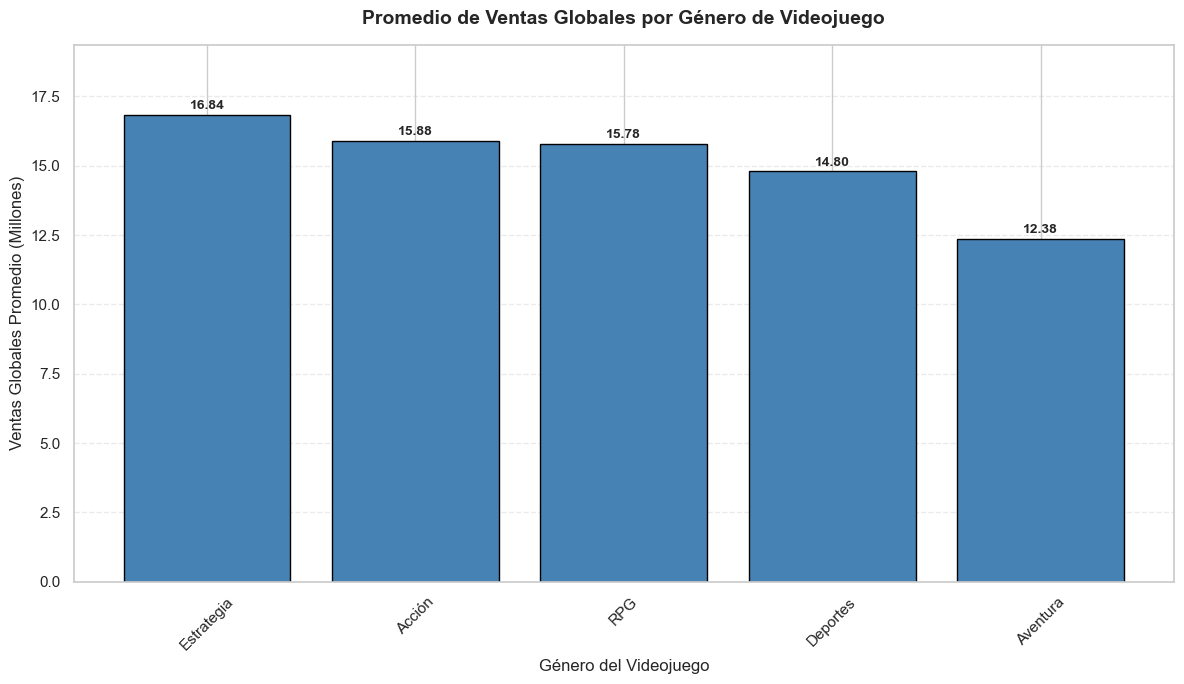

In [61]:


# Personalización Avanzada y Finalización
plt.figure(figsize=(12, 7))

# Añadir borde negro a las barras usando 'edgecolor' 
bars = plt.bar(ventas_por_genero.index, ventas_por_genero.values, 
                color='steelblue', edgecolor='black')

# Título y etiquetas de ejes 
plt.title('Promedio de Ventas Globales por Género de Videojuego', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Género del Videojuego', fontsize=12)
plt.ylabel('Ventas Globales Promedio (Millones)', fontsize=12)

# Fija los límites del eje Y para dar espacio visual a las notas 
# Establecemos el límite superior un 15% por encima del valor máximo
max_val = ventas_por_genero.values.max()
plt.ylim(0, max_val * 1.15)

# Añadir anotaciones de texto sobre cada barra con el valor exacto 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ajustes de formato y legibilidad 
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4) # Cuadrícula sutil para guiar la vista
plt.tight_layout()

# Guardar el gráfico final en el archivo solicitado 
plt.savefig('ventas_por_genero_personalizado.png')

plt.show()